(sw_tomography_sphere)=

# Surface-Wave Tomography on the Sphere

This tutorial mirrors {ref}`sw_tomography`, but treats the Earth's surface for what it is — a sphere. At the continental scale considered here, using longitude and latitude as Cartesian coordinates (as one could do with [bayesbay.discretization.Voronoi2D](../api/generated/bayesbay.discretization.Voronoi2D)) would introduce a metric distortion that grows with the extent of the study area: one degree of longitude at 46°N is ~30% shorter than at 30°N. We therefore parameterize the velocity structure through [bayesbay.discretization.Voronoi2DSphere](../api/generated/bayesbay.discretization.Voronoi2DSphere), a trans-dimensional Voronoi tessellation defined in terms of great-circle distances, with sites expressed as longitude-latitude pairs in degrees.

Along the way, we showcase two features of `Voronoi2DSphere`:

- **Region of interest**: an arbitrary polygon in the longitude-latitude plane — consistent with typical GIS boundary data — delimits where Voronoi sites are allowed;
- **Interpolation of the tessellation**: by registering the forward grid through `interpolation_positions`, each Markov chain state keeps track of the Voronoi cell each grid node belongs to, and the forward function interpolates the tessellation through a simple array lookup (see the *Interpolation under the hood* section below).

## Import libraries and define constants

As in {ref}`sw_tomography`, we make use of the [SeisLib](https://seislib.readthedocs.io/en/latest/) Python library to generate a synthetic velocity model — here defined on an equal-area grid — and to compute the Jacobian of the forward problem along great-circle paths. We also use [Cartopy](https://scitools.org.uk/cartopy/) to display our results in geographic coordinates and to constrain the position of the seismic receivers to dry land.

In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
import scipy
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.patch import geos_to_path
import shapely.geometry
import shapely.ops
import shapely.prepared

from seislib.tomography import SeismicTomography
from cmcrameri import cm as scm

from bayesbay.discretization import Voronoi2DSphere
from bayesbay.prior import UniformPrior
import bayesbay as bb

random.seed(10)
np.random.seed(10)

## Region of interest and true velocity model

Our study area is an irregular polygon roughly enclosing the Mediterranean region. The polygon is defined in the longitude-latitude plane (its edges are straight lines on an equirectangular map, as in typical GIS boundary data such as country or continent outlines); a `shapely.geometry.MultiPolygon` — e.g., disjoint patches — would work just as well.

Using SeisLib, the following block then defines a velocity model characterized by a checkerboard pattern, which we will attempt to retrieve through Bayesian inversion. Note that, in contrast with {ref}`sw_tomography`, the model is defined on an **equal-area grid**: each cell covers the same surface area on the sphere, regardless of latitude.

In [2]:
polygon = shapely.geometry.Polygon(
    [(-10, 30), (40, 30), (40, 40), (32, 47), (-2, 47), (-10, 40)]
)

tomo = SeismicTomography(
    cell_size=0.4,
    lonmin=-11,
    lonmax=41,
    latmin=29,
    latmax=48
    )
grid_points = np.column_stack(tomo.grid.midpoints_lon_lat())
vel_true = tomo.checkerboard(
    ref_value=3,
    kx=6,
    ky=3,
    lonmin=tomo.grid.lonmin,
    lonmax=tomo.grid.lonmax,
    latmin=tomo.grid.latmin,
    latmax=tomo.grid.latmax,
    anom_amp=0.3
    )(*grid_points.T)
print(f'{grid_points.shape[0]} equal-area grid cells')

-------------------------------------
Optimal grid found in 226 iterations
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -11.535 - 41.538
Latmin - Latmax : 28.801 - 48.400
Number of cells : 5003
Grid cells of 0.400° : 5003
-------------------------------------
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -11.535 - 41.538
Latmin - Latmax : 28.801 - 48.400
Number of cells : 5003
Grid cells of 0.400° : 5003
-------------------------------------
5003 equal-area grid cells


The velocity maps in this tutorial are restricted to the region of interest: we mask the triangles used by `tricontourf` whose centre falls outside the polygon, and paint everything beyond the polygon in white.

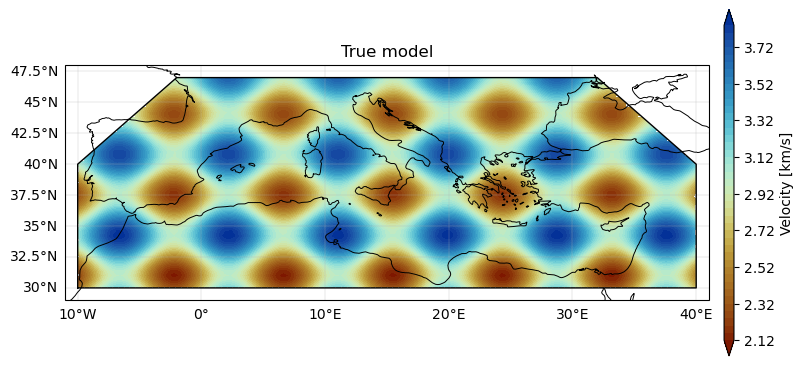

In [3]:
map_extent = [-11, 41, 29, 48]

# triangulation of the grid points, masked outside the region of interest
triangulation = tri.Triangulation(*grid_points.T)
centroids_lon = grid_points[:, 0][triangulation.triangles].mean(axis=1)
centroids_lat = grid_points[:, 1][triangulation.triangles].mean(axis=1)
prepared_polygon = shapely.prepared.prep(polygon)
triangulation.set_mask([
    not prepared_polygon.contains(shapely.geometry.Point(lon, lat))
    for lon, lat in zip(centroids_lon, centroids_lat)
])

# white patch covering everything outside the region of interest
outside_region = shapely.geometry.box(-180, -90, 180, 90).difference(polygon)
outside_path = geos_to_path(outside_region)[0]


def plot_map(values, title, ax=None, cbar_label='Velocity [km/s]', **kwargs):
    if ax is None:
        plt.figure(figsize=(10, 4.5))
        ax = plt.axes(projection=ccrs.PlateCarree())
    img = ax.tricontourf(triangulation,
                         values,
                         levels=50,
                         cmap=scm.roma,
                         transform=ccrs.PlateCarree(),
                         extend='both',
                         **kwargs)
    ax.add_patch(PathPatch(outside_path, facecolor='white', edgecolor='none',
                           transform=ccrs.PlateCarree(), zorder=2))
    ax.coastlines(resolution='50m', lw=0.7, zorder=3)
    ax.plot(*polygon.exterior.xy, 'k', lw=1, transform=ccrs.PlateCarree(), zorder=3)
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, lw=0.2)
    gl.top_labels = gl.right_labels = False
    cbar = plt.gcf().colorbar(img, ax=ax, aspect=35, pad=0.02)
    cbar.set_label(cbar_label)
    ax.set_title(title)
    return ax, cbar

plot_map(vel_true, 'True model', vmin=vel_true.min(), vmax=vel_true.max())
plt.show()

## Observed Data

The code block below generates coordinates for seismic sources and receivers. Forty sources are positioned along the boundary of the region of interest, while 50 receivers are placed randomly within it — with the additional condition that they fall on dry land, which we verify against the Natural Earth land polygons available through Cartopy. Utilizing SeisLib, we then compute the $m \times n$ Jacobian matrix $\mathbf{G}$, where $m$ denotes the number of source-receiver pairs (here, 2000) and $n$ the number of grid cells defining the velocity medium. $\mathbf{G}$ is defined such that $G_{ij} = \frac{l_j}{L_i}$, where $L_i$ is the great-circle length associated with the $i$th observation and $l_j$ is its segment within the $j$th grid cell ([Magrini et al. 2022](Magrini22b)). All path lengths are here computed along **great circles** on the sphere.

As in {ref}`sw_tomography`, we use the Jacobian matrix to define the observed surface-wave arrival times $\mathbf{d}_{obs} = \mathbf{G} \cdot \mathbf{s}_{true}$, where $\mathbf{s}_{true}$ denotes the reciprocal of the true velocity model.

In [4]:
def get_land_polygons():
    shp = shpreader.natural_earth(resolution='50m', category='physical', name='land')
    land = shapely.ops.unary_union(list(shpreader.Reader(shp).geometries()))
    return shapely.prepared.prep(land)


def get_sources_and_receivers(n_sources=40, n_receivers=50):
    land = get_land_polygons()
    # sources: evenly spaced along the boundary of the region of interest
    sources = np.array([
        polygon.exterior.interpolate(f, normalized=True).coords[0][::-1]  # (lat, lon)
        for f in np.linspace(0, 1, n_sources, endpoint=False)
    ])
    # receivers: random within the region of interest, on dry land
    lonmin, latmin, lonmax, latmax = polygon.bounds
    receivers = []
    while len(receivers) < n_receivers:
        lat, lon = np.random.uniform([latmin, lonmin], [latmax, lonmax])
        point = shapely.geometry.Point(lon, lat)
        if polygon.contains(point) and land.contains(point):
            receivers.append([lat, lon])
    return sources, np.array(receivers)


def add_data_coords(tomo, sources, receivers):
    data_coords = np.zeros((sources.shape[0] * receivers.shape[0], 4))
    for icoord, (isource, ireceiver) in enumerate(
            np.ndindex((sources.shape[0], receivers.shape[0]))
            ):
        data_coords[icoord] = np.concatenate(
            (sources[isource], receivers[ireceiver])
            )
    tomo.data_coords = data_coords


def compute_jacobian(tomo):
    tomo.compile_coefficients()
    jacobian = scipy.sparse.csr_matrix(tomo.A)
    del tomo.A
    return jacobian


sources, receivers = get_sources_and_receivers(n_sources=40, n_receivers=50)
add_data_coords(tomo, sources, receivers)
jacobian = compute_jacobian(tomo)
d_obs = jacobian @ (1/vel_true)

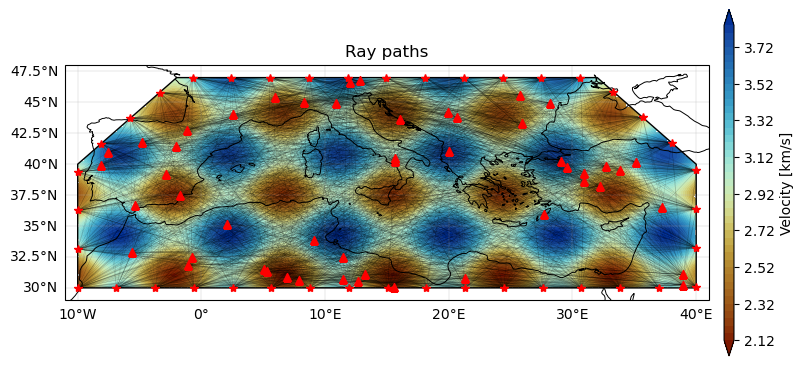

In [5]:
ax, cbar = plot_map(vel_true, 'Ray paths', vmin=vel_true.min(), vmax=vel_true.max())
# Sources and receivers cols are lat, lon; the rays, which propagate along
# great circles, are rendered as such through the Geodetic transform
geodetic = ccrs.Geodetic()
geodetic.threshold = 1e5
rays = [((lon1, lat1), (lon2, lat2)) for lat1, lon1, lat2, lon2 in tomo.data_coords]
ax.add_collection(LineCollection(rays, transform=geodetic, lw=0.2, color='k', alpha=0.3, zorder=4))
ax.plot(sources[:, 1], sources[:, 0], 'r*', transform=ccrs.PlateCarree(), zorder=5, clip_on=False)
ax.plot(receivers[:, 1], receivers[:, 0], 'r^', transform=ccrs.PlateCarree(), zorder=5)
plt.show()

## Inference parameterization

We parameterize the velocity model through a trans-dimensional Voronoi tessellation on the sphere, whose number of cells is a free parameter of the inversion, allowed to vary between 50 and 1500; within each cell, the velocity is uniformly distributed a priori between 2 and 4 km/s. Compared with {ref}`sw_tomography`, note that (i) no `vmin`/`vmax` are needed, since the domain of a `Voronoi2DSphere` is the sphere itself, here restricted to the region of interest through `polygon`; (ii) `perturb_std` expresses the per-axis scale of the local tangent-plane site displacement, **in degrees**, like the site coordinates; and (iii) we register our spatial grid through `interpolation_positions`, which is used in the forward calculation below.

In [6]:
vel = UniformPrior('vel', vmin=2, vmax=4, perturb_std=0.1)
voronoi = Voronoi2DSphere(
    name='voronoi',
    perturb_std=1,
    polygon=polygon,
    n_dimensions_min=50,
    n_dimensions_max=1500,
    parameters=[vel],
    interpolation_positions=grid_points)
parameterization = bb.parameterization.Parameterization(voronoi)

## Log Likelihood

In the forward function, the velocity model is interpolated onto the grid through `get_interpolated_values`, which reads, from the cache of the current Markov chain state, the nearest-neighbour assignments of the grid points to the Voronoi cells; these are updated by BayesBay at every perturbation of the tessellation. The interpolated velocity is translated into surface-wave arrival times through the Jacobian matrix.

In [7]:
def forward(state):
    voronoi_state = state["voronoi"]
    interp_vel = voronoi.get_interpolated_values(voronoi_state, "vel")
    state.save_to_extra_storage("interp_vel", interp_vel)
    return jacobian @ (1 / interp_vel)

### Interpolation under the hood

`get_interpolated_values` performs a nearest-neighbour interpolation: each registered position takes the value of the Voronoi cell it belongs to, i.e., of the nearest Voronoi site in terms of great-circle distance. The index of that cell, for each registered position, is stored in the cache of every Markov chain state — the discretization object itself only holds the registered positions, so that each chain, and each state within a chain, carries its own assignments. Rather than being recomputed from scratch at every iteration, the assignments are updated at each perturbation of the tessellation, considering that a perturbation can only affect the positions within the perturbed Voronoi cells: after the birth of a new cell, the only positions that change assignment are those closer to the newborn site than to their current one; after a death, only the positions orphaned by the removed cell are re-assigned; and when a site moves, only the positions of its old cell, plus those now closer to its new location, are updated.

At a lower level, the cell assignments can be accessed through `get_nearest_site_indices`. The code block below verifies, on the initial state of the inference, that they coincide exactly with an explicit nearest-neighbour query, carried out via a kd-tree on the 3-D Cartesian representation of sites and grid (for which nearest neighbours in Euclidean distance coincide with nearest neighbours in great-circle distance).

In [8]:
state = parameterization.initialize()
voronoi_state = state["voronoi"]

# low-level access to the cell assignments maintained by Voronoi2DSphere
nearest = voronoi.get_nearest_site_indices(voronoi_state)

# equivalent, explicit nearest-neighbour query
kdtree = scipy.spatial.KDTree(
    Voronoi2DSphere.lonlat_to_xyz(voronoi_state["discretization"])
)
nearest_explicit = kdtree.query(Voronoi2DSphere.lonlat_to_xyz(grid_points))[1]

assert np.array_equal(nearest, nearest_explicit)
assert np.array_equal(
    voronoi.get_interpolated_values(voronoi_state, "vel"),
    voronoi_state["vel"][nearest]
)
print('cached cell assignments == explicit kd-tree query:',
      np.array_equal(nearest, nearest_explicit))

cached cell assignments == explicit kd-tree query: True


In [9]:
target = bb.likelihood.Target('d_obs',
                              d_obs,
                              std_min=0,
                              std_max=0.01,
                              std_perturb_std=0.001,
                              noise_is_correlated=False)
log_likelihood = bb.likelihood.LogLikelihood(targets=target, fwd_functions=forward)

## Bayesian Inference

We sample the posterior through multiple Markov chains run in parallel, discarding the initial burn-in iterations and saving one model every `save_every` iterations thereafter. The saved states include, for each sampled model, the Voronoi-site positions, the associated velocities, and the velocity field interpolated onto the grid (stored in the forward function via `save_to_extra_storage`).

In [10]:
inversion = bb.BayesianInversion(
    parameterization=parameterization,
    log_likelihood=log_likelihood,
    n_chains=20
)
inversion.run(
    sampler=None,
    n_iterations=30_000,
    burnin_iterations=15_000,
    save_every=250,
    verbose=False,
    print_every=25_000
)

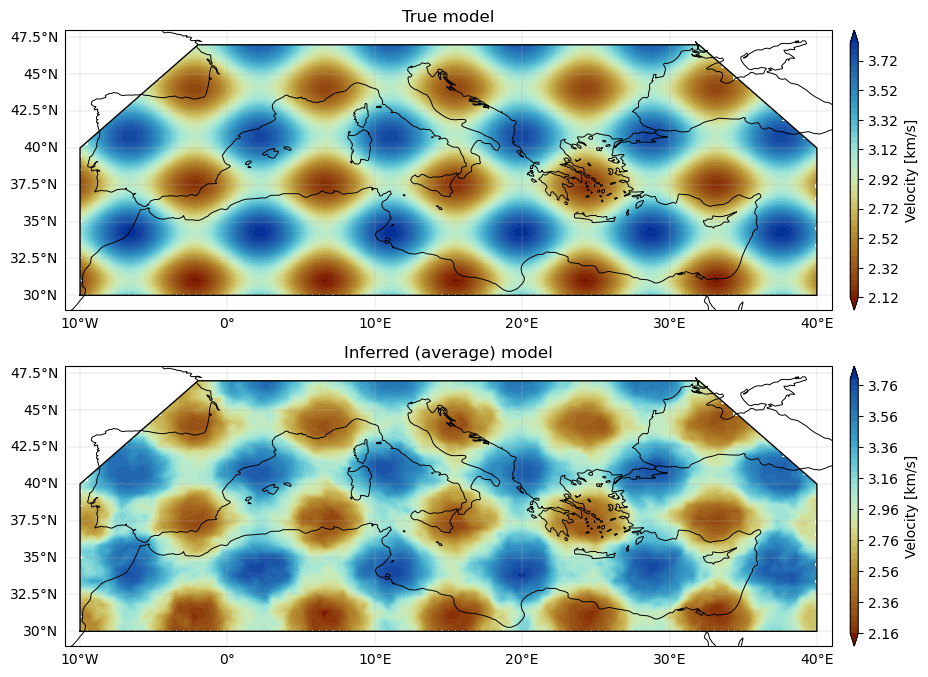

In [11]:
results = inversion.get_results()
inferred_vel = np.mean(results['interp_vel'], axis=0)

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
plot_map(vel_true, 'True model', ax=ax1, vmin=vel_true.min(), vmax=vel_true.max())
ax2 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
plot_map(inferred_vel, 'Inferred (average) model', ax=ax2, vmin=vel_true.min(), vmax=vel_true.max())
plt.show()

The code block below displays a few models sampled from the posterior. Each panel shows the exact spherical Voronoi cells of one sampled tessellation, clipped to the region of interest; all panels share the same color scale.

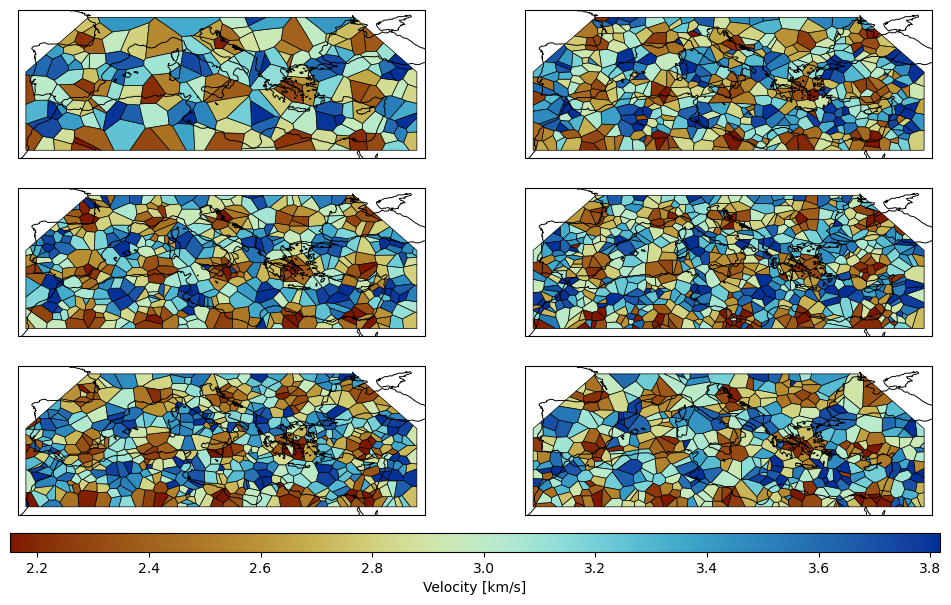

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
norm = plt.Normalize(vmin=inferred_vel.min(), vmax=inferred_vel.max())
random_indexes = np.random.choice(range(len(results['voronoi.vel'])), size=6, replace=False)
for ax, irandom in zip(axes.ravel(), random_indexes):
    voronoi_sites = results['voronoi.discretization'][irandom]
    velocity = results['voronoi.vel'][irandom]
    Voronoi2DSphere.plot_tessellation(
        voronoi_sites,
        velocity,
        ax=ax,
        clip_polygon=polygon,
        cmap=scm.roma,
        norm=norm,
        colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.coastlines(resolution='50m', lw=0.7)
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
cbar = fig.colorbar(ScalarMappable(cmap=scm.roma, norm=norm), ax=axes.ravel().tolist(),
                    orientation='horizontal', aspect=50, pad=0.03)
cbar.set_label('Velocity [km/s]')
plt.show()

## References

(Magrini22b)=
[1] Magrini et al. (2022), Surface-wave tomography using SeisLib: a Python package for multiscale seismic imaging. *Geophysical Journal International*